In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Section A: Basic Exploration**

In [9]:
# Loading Data
df = pd.read_csv("/content/car_MSRP.csv")

In [10]:
# Print all column names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Make                                          11914 non-null  object 
 1   Model                                         11914 non-null  object 
 2   Year                                          11914 non-null  int64  
 3   Engine Fuel Type                              11911 non-null  object 
 4   Engine HP                                     11845 non-null  float64
 5   Engine Cylinders                              11884 non-null  float64
 6   Transmission Type                             11914 non-null  object 
 7   Driven_Wheels                                 11914 non-null  object 
 8   Number of Doors                               11908 non-null  float64
 9   Market Category                               8172 non-null  

In [11]:
#Check the data type of every column.
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [12]:
#Display the first 5 rows.
df.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP (Manufacturer's suggested retail Price)
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [13]:
#Display 10 random rows
df.sample(10)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP (Manufacturer's suggested retail Price)
11110,Volvo,V50,2009,premium unleaded (recommended),227.0,5.0,AUTOMATIC,all wheel drive,4.0,Luxury,Compact,Wagon,26,18,870,35500
2670,Chevrolet,C/K 2500 Series,1998,regular unleaded,230.0,8.0,MANUAL,rear wheel drive,2.0,NaN,Large,Regular Cab Pickup,17,13,1385,2697
1609,Toyota,Avalon,2017,regular unleaded,268.0,6.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,30,21,2031,35000
4720,Honda,Fit,2017,regular unleaded,130.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,40,33,2202,16790
2414,Volkswagen,CC,2016,premium unleaded (recommended),200.0,4.0,MANUAL,front wheel drive,4.0,Performance,Midsize,Sedan,32,21,873,31570
2834,Plymouth,Colt,1994,regular unleaded,136.0,4.0,MANUAL,front wheel drive,4.0,NaN,Compact,Wagon,25,19,535,2000
701,Maybach,62,2012,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Sedan,16,10,67,470350
1029,Audi,A3,2016,premium unleaded (recommended),220.0,4.0,AUTOMATED_MANUAL,all wheel drive,4.0,Luxury,Compact,Sedan,33,24,3105,34200
9599,Chevrolet,Silverado 1500,2016,flex-fuel (unleaded/E85),285.0,6.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,22,17,1385,40495
7824,Audi,Q5,2017,premium unleaded (required),272.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Luxury",Midsize,4dr SUV,26,18,3105,46400


In [14]:
#Count total missing values in the dataset.
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


In [15]:
# Find which column has the most missing values.
max_missing_column = df.isnull().sum().idxmax()
print("Column with the most missing values:", max_missing_column)

Column with the most missing values: Market Category


In [16]:
#Calculate the percentage of missing values in Market Category.
df.isnull().sum() / len(df) * 100

,0
Make,0.000000
Model,0.000000
Year,0.000000
Engine Fuel Type,0.025180
Engine HP,0.579151
Engine Cylinders,0.251805
Transmission Type,0.000000
Driven_Wheels,0.000000
Number of Doors,0.050361
Market Category,31.408427


In [17]:
# fill missing values
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].mode()[0])
df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].mode()[0])
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].mean())
df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

In [18]:
# Count the number of duplicate rows
df.duplicated().sum()

np.int64(715)

In [19]:
#before removinng duplicates
df.shape

(11914, 16)

In [20]:
# Remove duplicate rows and check the new shape.
df.drop_duplicates()
df.shape

(11914, 16)

In [21]:
# List all numerical columns.
num_col = df.select_dtypes(include=np.number).columns.tolist()


In [22]:
#List all categorical (text) columns.
cat_cols = df.select_dtypes(include=object).columns.tolist()
print(cat_cols)

['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']


In [23]:
#Get the statistical summary of MSRP using .describe().
df["MSRP (Manufacturer's suggested retail Price)"].describe()

,MSRP (Manufacturer's suggested retail Price)
count,1.191400e+04
mean,4.059474e+04
std,6.010910e+04
min,2.000000e+03
25%,2.100000e+04
50%,2.999500e+04
75%,4.223125e+04
max,2.065902e+06


In [24]:
# Get the statistical summary of all categorical columns.
df[cat_cols].describe()

,Make,Model,Engine Fuel Type,Transmission Type,Driven_Wheels,Market Category,Vehicle Size,Vehicle Style
count,11914,11914,11914,11914,11914,8172,11914,11914
unique,48,915,10,5,4,71,3,16
top,Chevrolet,Silverado 1500,regular unleaded,AUTOMATIC,front wheel drive,Crossover,Compact,Sedan
freq,1123,156,7175,8266,4787,1110,4764,3048


In [25]:
# Check the memory usage of the dataset.
df.memory_usage()

,0
Index,132
Make,95312
Model,95312
Year,95312
Engine Fuel Type,95312
Engine HP,95312
Engine Cylinders,95312
Transmission Type,95312
Driven_Wheels,95312
Number of Doors,95312


In [26]:
# renaming the MSRP (Manufacturer's suggested retail Price)
df.rename(columns={"MSRP (Manufacturer's suggested retail Price)": "MSRP"}, inplace=True)

**Section B: Univariate Analysis of Numerical Columns**

In [27]:
# Find the mean, median, and mode of MSRP.
df["MSRP"].describe()

,MSRP
count,1.191400e+04
mean,4.059474e+04
std,6.010910e+04
min,2.000000e+03
25%,2.100000e+04
50%,2.999500e+04
75%,4.223125e+04
max,2.065902e+06


In [28]:
#Find the minimum and maximum MSRP in the dataset.
df["MSRP"].max()

2065902

In [29]:
df["MSRP"].min()

2000

<Axes: >

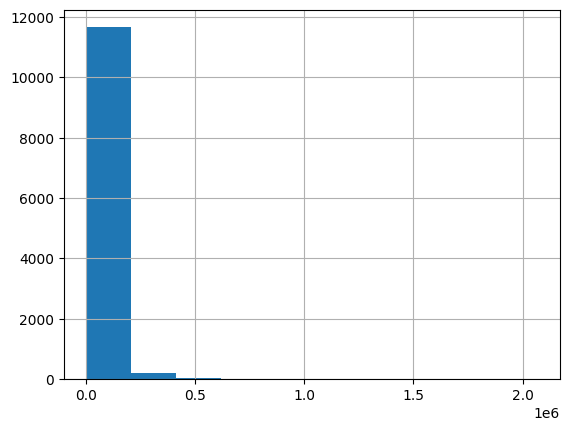

In [30]:
# Plot a histogram of MSRP.
df["MSRP"].hist()

<Axes: >

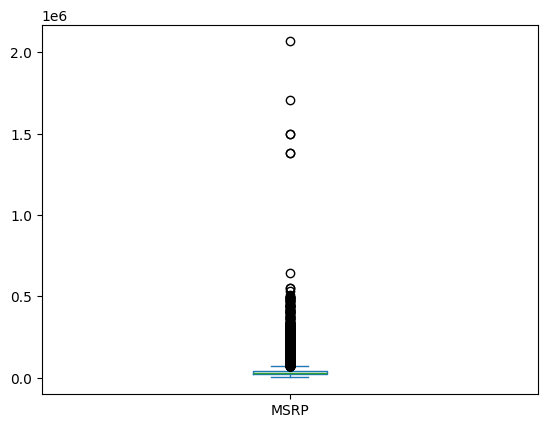

In [31]:
#Plot a boxplot of MSRP and identify outliers.
df["MSRP"].plot(kind="box")

In [32]:
# Calculate the skewness of MSRP — is it left-skewed or right-skewed?
df["MSRP"].skew()

np.float64(11.771987129334972)

<Axes: >

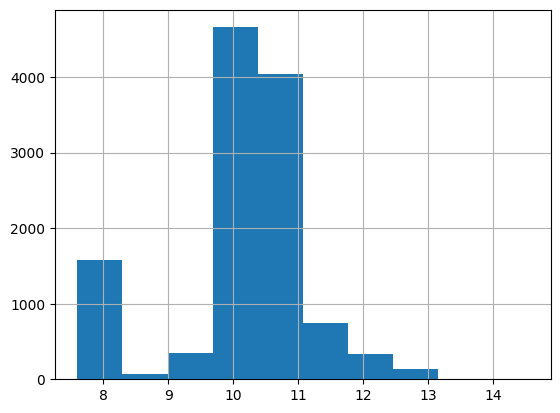

In [33]:
# Apply a log transformation to MSRP and re-plot the histogram.
df["log_MSRP"] = np.log(df["MSRP"])
df["log_MSRP"].hist()


In [34]:
# Find the average Engine HP across all cars.
df["Engine HP"].mean()

np.float64(249.38607007176023)

In [118]:
print(df.duplicated().sum())

715


In [119]:
#deoping duplicates
df.drop_duplicates(inplace=True)

In [121]:
# Drop unwanted/unnecessary columns
df = df.drop(columns=['Market Category', 'Popularity', 'Number of Doors'], errors='ignore')

In [123]:
num_col = df.select_dtypes(include=np.number).columns.tolist()
print(num_col)

['Year', 'Engine HP', 'Engine Cylinders', 'highway MPG', 'city mpg', 'MSRP', 'log_MSRP', 'MSRP_per_Engine_HP', 'HP_per_Cylinder']


In [124]:
cat_col = df.select_dtypes(include=object).columns.tolist()
print(cat_col)

['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Vehicle Size', 'Vehicle Style']


In [125]:
# handling values
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].mode()[0])
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].mean())

In [126]:
df.describe()

,Year,Engine HP,Engine Cylinders,highway MPG,city mpg,MSRP,log_MSRP,MSRP_per_Engine_HP,HP_per_Cylinder
count,11199.000000,11199.000000,11199.000000,11199.000000,11199.000000,1.119900e+04,11199.000000,11199.000000,1.119900e+04
mean,2010.714528,253.364197,5.661488,26.610590,19.731851,4.192593e+04,10.171988,143.572466,inf
std,7.228211,109.811495,1.796677,8.977641,9.177555,6.153505e+04,1.062471,100.646363,NaN
min,1990.000000,55.000000,0.000000,12.000000,7.000000,2.000000e+03,7.600902,7.142857,1.550000e+01
25%,2007.000000,172.000000,4.000000,22.000000,16.000000,2.159950e+04,9.980425,111.748873,3.500000e+01
50%,2015.000000,240.000000,6.000000,25.000000,18.000000,3.067500e+04,10.331203,134.846154,4.437500e+01
75%,2016.000000,303.000000,6.000000,30.000000,22.000000,4.303250e+04,10.669711,162.986618,5.066667e+01
max,2017.000000,1001.000000,16.000000,354.000000,137.000000,2.065902e+06,14.541077,2307.692308,inf


In [35]:
# Find outliers in Engine HP using the IQR method.
Q1 = df['Engine HP'].quantile(0.25)
Q3 = df['Engine HP'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Engine HP'] < lower_bound) | (df['Engine HP'] > upper_bound)]
print("Outliers in Engine HP:")
print(outliers)

Outliers in Engine HP:
          Make       Model  Year             Engine Fuel Type  Engine HP  \
466    Ferrari  458 Italia  2013  premium unleaded (required)      562.0   
467    Ferrari  458 Italia  2013  premium unleaded (required)      562.0   
468    Ferrari  458 Italia  2014  premium unleaded (required)      562.0   
469    Ferrari  458 Italia  2014  premium unleaded (required)      597.0   
470    Ferrari  458 Italia  2014  premium unleaded (required)      562.0   
...        ...         ...   ...                          ...        ...   
11509      BMW        X5 M  2016  premium unleaded (required)      567.0   
11510      BMW        X5 M  2017  premium unleaded (required)      567.0   
11523      BMW        X6 M  2015  premium unleaded (required)      567.0   
11524      BMW        X6 M  2016  premium unleaded (required)      567.0   
11525      BMW        X6 M  2017  premium unleaded (required)      567.0   

       Engine Cylinders Transmission Type     Driven_Wheels  Num

In [36]:
# Find the most common value in Engine Cylinders.
df["Engine Cylinders"].value_counts()

,count
Engine Cylinders,
4.0,4782
6.0,4489
8.0,2031
12.0,230
5.0,225
10.0,68
0.0,56
3.0,30
16.0,3


<Axes: xlabel='Engine Cylinders'>

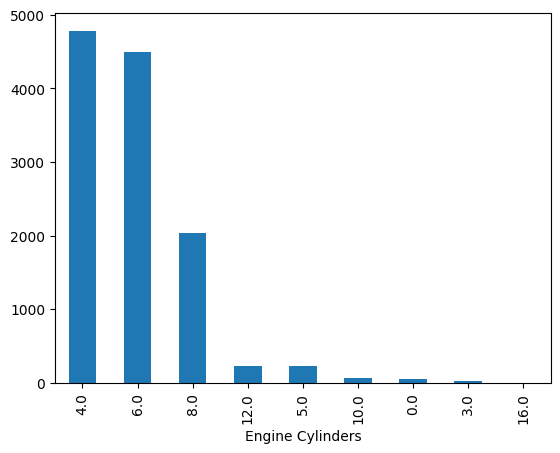

In [37]:
# Plot a count plot of Engine Cylinders.
df["Engine Cylinders"].value_counts().plot(kind="bar")


In [38]:
# Find the distribution of Year — which years have the most cars listed?
df["Year"].value_counts()

,count
Year,
2015,2170
2016,2157
2017,1668
2014,589
2012,387
2009,379
2013,366
2008,349
2007,345


<Axes: >

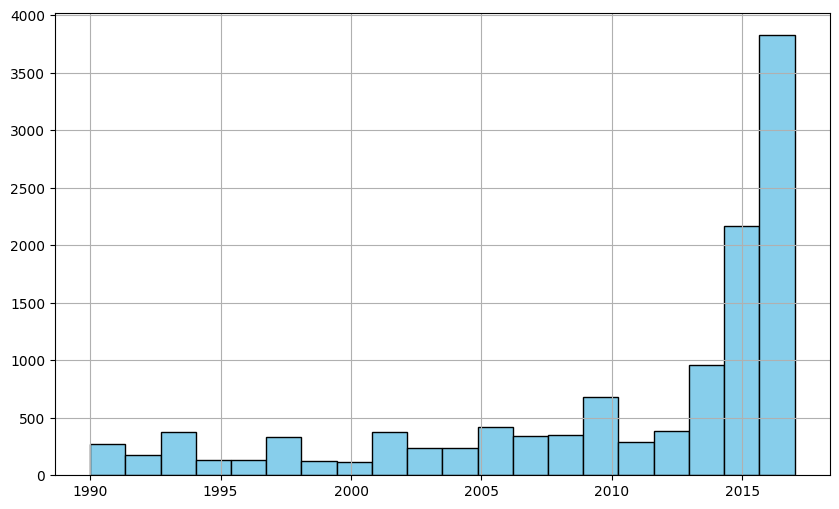

In [39]:
# Plot a histogram of Year.
df["Year"].hist(
    bins=20,
    figsize=(10, 6),
    color="skyblue",
    edgecolor="black"
)

In [40]:
# Find the average highway MPG and city mpg.
df[["highway MPG", "city mpg"]].mean()

,0
highway MPG,26.637485
city mpg,19.733255


<Axes: >

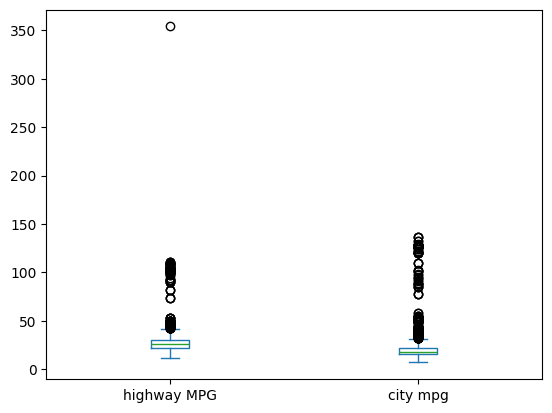

In [41]:
# Plot boxplots for highway MPG and city mpg.
df[["highway MPG", "city mpg"]].plot(kind="box")

In [42]:
#Find outliers in city mpg.
Q1 = df['city mpg'].quantile(0.25)
Q3 = df['city mpg'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['city mpg'] < lower_bound) | (df['city mpg'] > upper_bound)]
print("Outliers in city mpg:")
print(outliers)

Outliers in city mpg:
         Make           Model  Year  Engine Fuel Type  Engine HP  \
135       BMW        3 Series  2015            diesel  180.00000   
146       BMW        3 Series  2016            diesel  180.00000   
161       BMW        3 Series  2017            diesel  180.00000   
539      FIAT            500e  2015          electric  249.38607   
540      FIAT            500e  2016          electric  249.38607   
...       ...             ...   ...               ...        ...   
10792   Mazda  Tribute Hybrid  2008  regular unleaded  133.00000   
10795   Mazda  Tribute Hybrid  2008  regular unleaded  133.00000   
10796   Mazda  Tribute Hybrid  2009  regular unleaded  177.00000   
10797   Mazda  Tribute Hybrid  2009  regular unleaded  177.00000   
11810  Toyota        Yaris iA  2017  regular unleaded  106.00000   

       Engine Cylinders Transmission Type      Driven_Wheels  Number of Doors  \
135                 4.0         AUTOMATIC   rear wheel drive              4.0   

In [43]:
# Find the distribution of Popularity — is it skewed?
df["Popularity"].value_counts()

,count
Popularity,
1385,1123
5657,881
873,809
2031,746
1851,626
2009,558
549,515
2202,449
586,423


<Axes: >

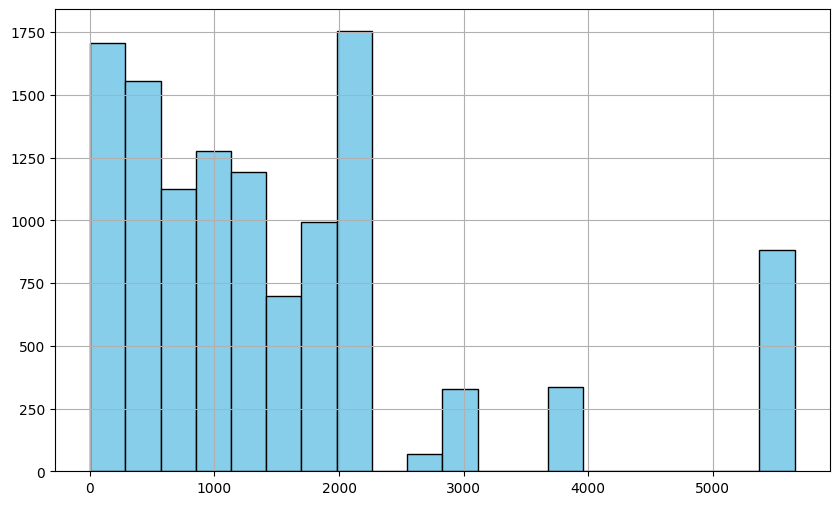

In [44]:
# Plot a histogram of Popularity.
df["Popularity"].hist(
    bins=20,
    figsize=(10, 6),
    color="skyblue",
    edgecolor="black"
)

In [45]:
# Find the most common Number of Doors.
df["Number of Doors"].value_counts()

,count
Number of Doors,
4.0,8359
2.0,3160
3.0,395


**Categorical Columns**

In [46]:
# Find how many unique car Makes are in the dataset.
df["Make"].unique()

array(['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler', 'Nissan',
       'Volvo', 'Mazda', 'Mitsubishi', 'Ferrari', 'Alfa Romeo', 'Toyota',
       'McLaren', 'Maybach', 'Pontiac', 'Porsche', 'Saab', 'GMC',
       'Hyundai', 'Plymouth', 'Honda', 'Oldsmobile', 'Suzuki', 'Ford',
       'Cadillac', 'Kia', 'Bentley', 'Chevrolet', 'Dodge', 'Lamborghini',
       'Lincoln', 'Subaru', 'Volkswagen', 'Spyker', 'Buick', 'Acura',
       'Rolls-Royce', 'Maserati', 'Lexus', 'Aston Martin', 'Land Rover',
       'Lotus', 'Infiniti', 'Scion', 'Genesis', 'HUMMER', 'Tesla',
       'Bugatti'], dtype=object)

In [47]:
len(df["Make"].unique())

48

In [48]:
# Which Make appears most frequently in the dataset?
df["Make"].value_counts()

,count
Make,
Chevrolet,1123
Ford,881
Volkswagen,809
Toyota,746
Dodge,626
Nissan,558
GMC,515
Honda,449
Mazda,423


<Axes: xlabel='Make'>

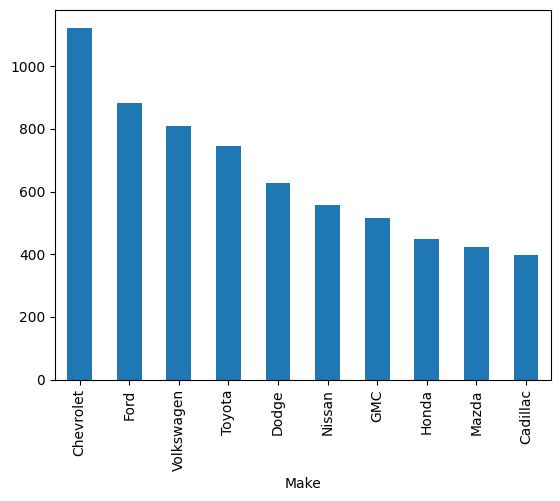

In [49]:
# Plot a bar chart of the top 10 most frequent Makes.
df["Make"].value_counts().head(10).plot(kind="bar")

In [50]:
# Find how many unique Models exist.
df["Model"].unique()

array(['1 Series M', '1 Series', '100', '124 Spider', '190-Class',
       '2 Series', '200', '200SX', '240SX', '240', '2',
       '3 Series Gran Turismo', '3 Series', '300-Class', '3000GT', '300',
       '300M', '300ZX', '323', '350-Class', '350Z', '360', '370Z', '3',
       '4 Series Gran Coupe', '4 Series', '400-Class', '420-Class',
       '456M', '458 Italia', '4C', '4Runner', '5 Series Gran Turismo',
       '5 Series', '500-Class', '500e', '500', '500L', '500X', '550',
       '560-Class', '570S', '575M', '57', '599', '5',
       '6 Series Gran Coupe', '6 Series', '600-Class', '6000',
       '612 Scaglietti', '626', '62', '650S Coupe', '650S Spider', '6',
       '7 Series', '718 Cayman', '740', '760', '780', '8 Series', '80',
       '850', '86', '9-2X', '9-3 Griffin', '09-Mar', '9-4X', '09-May',
       '9-7X', '9000', '900', '90', '911', '928', '929', '940', '944',
       '960', '968', 'A3', 'A4 allroad', 'A4', 'A5', 'A6', 'A7', 'A8',
       'Acadia Limited', 'Acadia', 'Accent', 'Ac

In [51]:
len(df["Model"].unique())

915

In [52]:
# Find the unique values in Transmission Type.
df["Transmission Type"].unique()

array(['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL', 'DIRECT_DRIVE',
       'UNKNOWN'], dtype=object)

In [53]:
len(df["Transmission Type"].unique())

5

<Axes: xlabel='Transmission Type'>

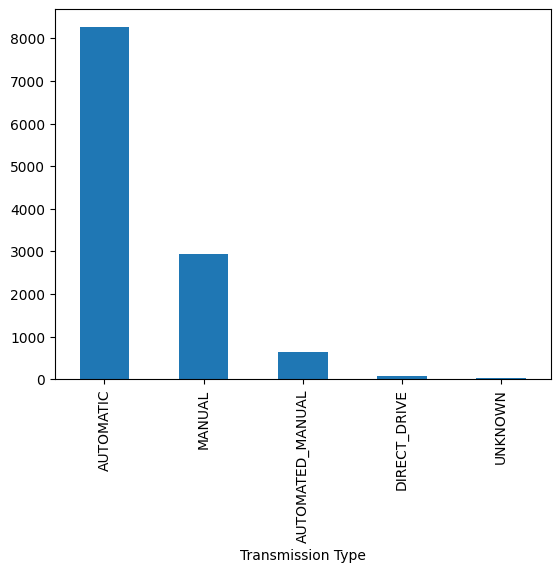

In [54]:
# Plot a count plot of Transmission Type.
df["Transmission Type"].value_counts().plot(kind="bar")

In [55]:
# Find the unique values in Driven_Wheels.
df["Driven_Wheels"].unique()

array(['rear wheel drive', 'front wheel drive', 'all wheel drive',
       'four wheel drive'], dtype=object)

In [56]:
len(df["Driven_Wheels"].unique())

4

<Axes: xlabel='Driven_Wheels'>

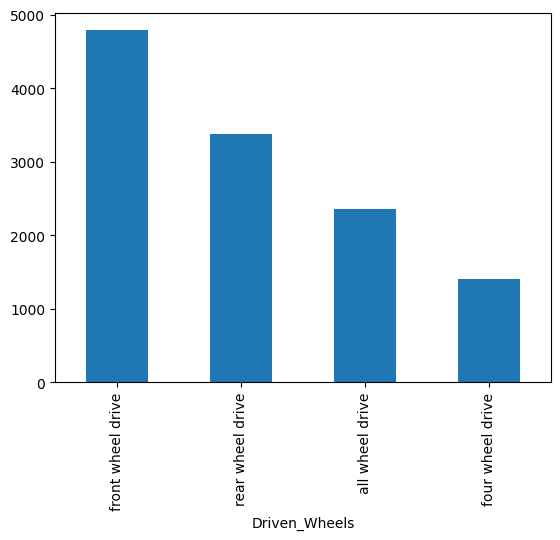

In [57]:
# Plot a bar chart of Driven_Wheels.
df["Driven_Wheels"].value_counts().plot(kind="bar")

In [58]:
# Find the unique values in Vehicle Size.
df["Vehicle Size"].unique()

array(['Compact', 'Midsize', 'Large'], dtype=object)

In [59]:
len(df["Vehicle Size"].unique())

3

<Axes: ylabel='count'>

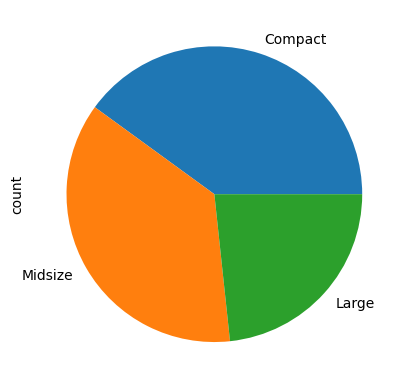

In [60]:
 # Plot a pie chart of Vehicle Size distribution.
df["Vehicle Size"].value_counts().plot(kind="pie")

In [61]:
# Find the unique values in Vehicle Style.
df['Driven_Wheels'].unique()

array(['rear wheel drive', 'front wheel drive', 'all wheel drive',
       'four wheel drive'], dtype=object)

In [62]:
len(df["Vehicle Style"].unique())

16

<Axes: xlabel='Vehicle Style'>

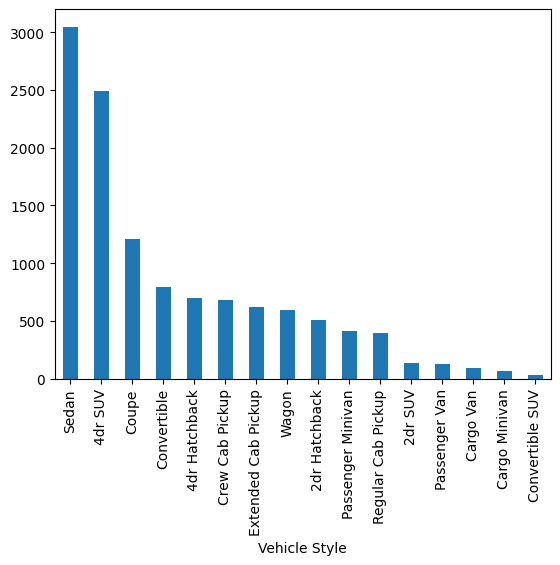

In [63]:
# Plot a bar chart of Vehicle Style frequency.
df["Vehicle Style"].value_counts().plot(kind="bar")

In [64]:
# Find the unique values in Engine Fuel Type.
df["Engine Fuel Type"].unique()

array(['premium unleaded (required)', 'regular unleaded',
       'premium unleaded (recommended)', 'flex-fuel (unleaded/E85)',
       'diesel', 'electric',
       'flex-fuel (premium unleaded recommended/E85)', 'natural gas',
       'flex-fuel (premium unleaded required/E85)',
       'flex-fuel (unleaded/natural gas)'], dtype=object)

In [65]:
len(df["Engine Fuel Type"].unique())

10

In [66]:
# Which Engine Fuel Type is most common?
df["Engine Fuel Type"].value_counts()

,count
Engine Fuel Type,
regular unleaded,7175
premium unleaded (required),2009
premium unleaded (recommended),1523
flex-fuel (unleaded/E85),899
diesel,154
electric,66
flex-fuel (premium unleaded required/E85),54
flex-fuel (premium unleaded recommended/E85),26
flex-fuel (unleaded/natural gas),6


In [67]:
# Check the cardinality of Market Category (how many unique combinations exist).
df["Market Category"].unique()

array(['Factory Tuner,Luxury,High-Performance', 'Luxury,Performance',
       'Luxury,High-Performance', 'Luxury', 'Performance', 'Flex Fuel',
       'Flex Fuel,Performance', nan, 'Hatchback',
       'Hatchback,Luxury,Performance', 'Hatchback,Luxury',
       'Luxury,High-Performance,Hybrid', 'Diesel,Luxury',
       'Hatchback,Performance', 'Hatchback,Factory Tuner,Performance',
       'High-Performance', 'Factory Tuner,High-Performance',
       'Exotic,High-Performance', 'Exotic,Factory Tuner,High-Performance',
       'Factory Tuner,Performance', 'Crossover', 'Exotic,Luxury',
       'Exotic,Luxury,High-Performance', 'Exotic,Luxury,Performance',
       'Factory Tuner,Luxury,Performance', 'Flex Fuel,Luxury',
       'Crossover,Luxury', 'Hatchback,Factory Tuner,Luxury,Performance',
       'Crossover,Hatchback', 'Hybrid', 'Luxury,Performance,Hybrid',
       'Crossover,Luxury,Performance,Hybrid',
       'Crossover,Luxury,Performance',
       'Exotic,Factory Tuner,Luxury,High-Performance',
   

In [68]:
len(df["Market Category"].unique())

72

In [69]:
# Handle the missing values in Market Category — fill with "Unknown" or drop.
df["Market Category"].fillna("Unknown", inplace=True)


/tmp/ipykernel_1447/3541901191.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Market Category"].fillna("Unknown", inplace=True)


** Section C: Bivariate Analysis  Numerical vs Numerical **

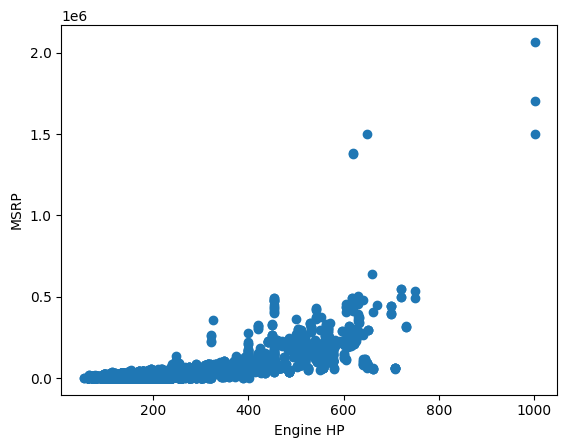

In [70]:
# Plot a scatter plot between Engine HP and MSRP.
import matplotlib.pyplot as plt
plt.scatter(df["Engine HP"], df["MSRP"])
plt.xlabel("Engine HP")
plt.ylabel("MSRP")
plt.show()

In [71]:
# Find the correlation coefficient between Engine HP and MSRP.
df["Engine HP"].corr(df["MSRP"])

np.float64(0.6616442014272397)

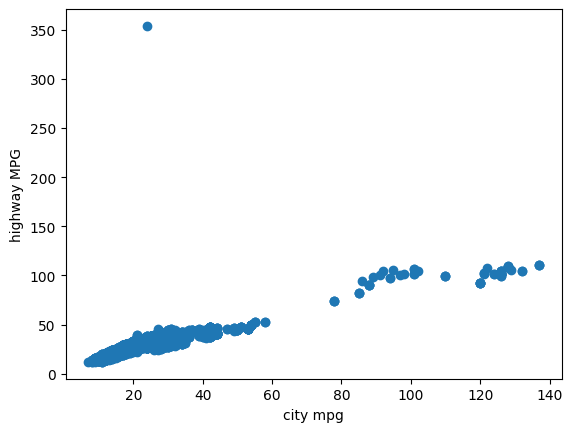

In [72]:
# Plot a scatter plot between city mpg and highway MPG.
plt.scatter(df["city mpg"],df["highway MPG"])
plt.xlabel("city mpg")
plt.ylabel("highway MPG")
plt.show()

In [73]:
# Find the correlation between city mpg and highway MPG.
df["city mpg"].corr(df["highway MPG"])

np.float64(0.8868294962591357)

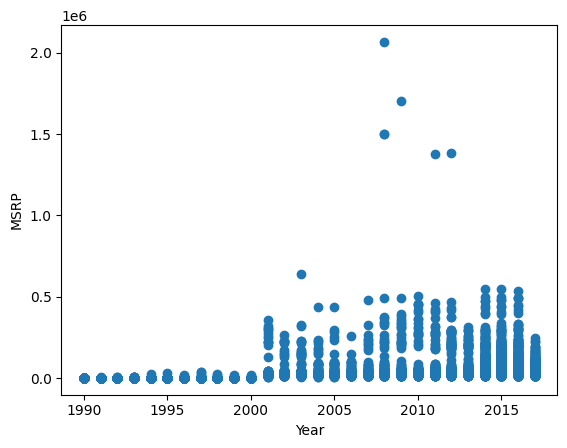

In [74]:
#Find the correlation between city mpg and highway MPG.
plt.scatter(df["Year"],df["MSRP"])
plt.xlabel("Year")
plt.ylabel("MSRP")
plt.show()

In [75]:
#Check if newer cars (Year) tend to have higher MSRP.
df["Year"].corr(df["MSRP"])

np.float64(0.22758951410473427)

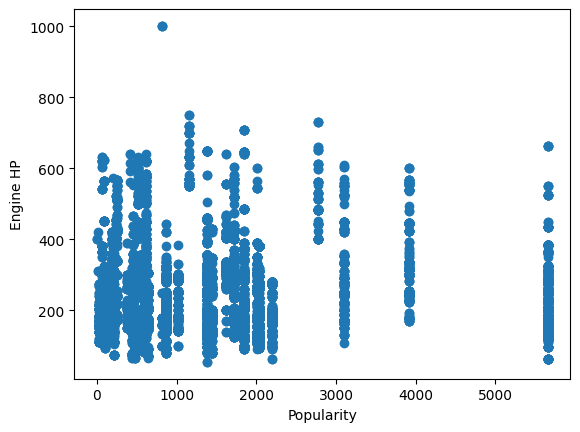

In [76]:
# Plot a scatter plot between Engine Cylinders and Engine HP.
plt.scatter(df["Popularity"],df["Engine HP"])
plt.xlabel("Popularity")
plt.ylabel("Engine HP")
plt.show()

In [77]:
#Find the correlation between Engine Cylinders and city mpg.
df["Engine Cylinders"].corr(df["city mpg"])

np.float64(-0.5743818305880843)

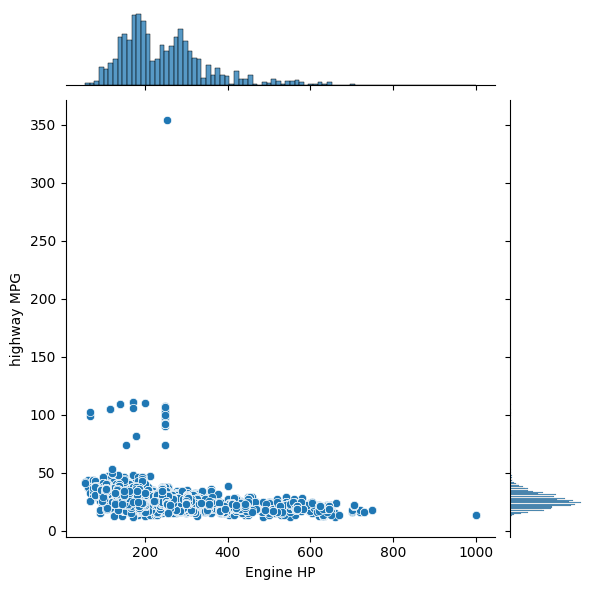

In [78]:
# Plot a joint plot between Engine HP and highway MPG.
import seaborn as sns
sns.jointplot(data=df, x="Engine HP", y="highway MPG", kind="scatter")

In [79]:
# Does Popularity correlate with MSRP?
df["Popularity"].corr(df["MSRP"])

np.float64(-0.04847623245504457)

**Numerical vs Categorical**

In [80]:
# Compare the average MSRP across different Makes (top 10)
avg_mrsp = df.groupby("Make")["MSRP"].mean()
print(avg_mrsp)


Make
Acura            3.488759e+04
Alfa Romeo       6.160000e+04
Aston Martin     1.979104e+05
Audi             5.345211e+04
BMW              6.154676e+04
Bentley          2.471693e+05
Bugatti          1.757224e+06
Buick            2.820661e+04
Cadillac         5.623132e+04
Chevrolet        2.835039e+04
Chrysler         2.672296e+04
Dodge            2.239006e+04
FIAT             2.267024e+04
Ferrari          2.382188e+05
Ford             2.739927e+04
GMC              3.049330e+04
Genesis          4.661667e+04
HUMMER           3.646441e+04
Honda            2.667434e+04
Hyundai          2.459704e+04
Infiniti         4.239421e+04
Kia              2.531017e+04
Lamborghini      3.315673e+05
Land Rover       6.782322e+04
Lexus            4.754907e+04
Lincoln          4.283983e+04
Lotus            6.918828e+04
Maserati         1.142077e+05
Maybach          5.462219e+05
Mazda            2.003938e+04
McLaren          2.398050e+05
Mercedes-Benz    7.147623e+04
Mitsubishi       2.124054e+04
Nissa

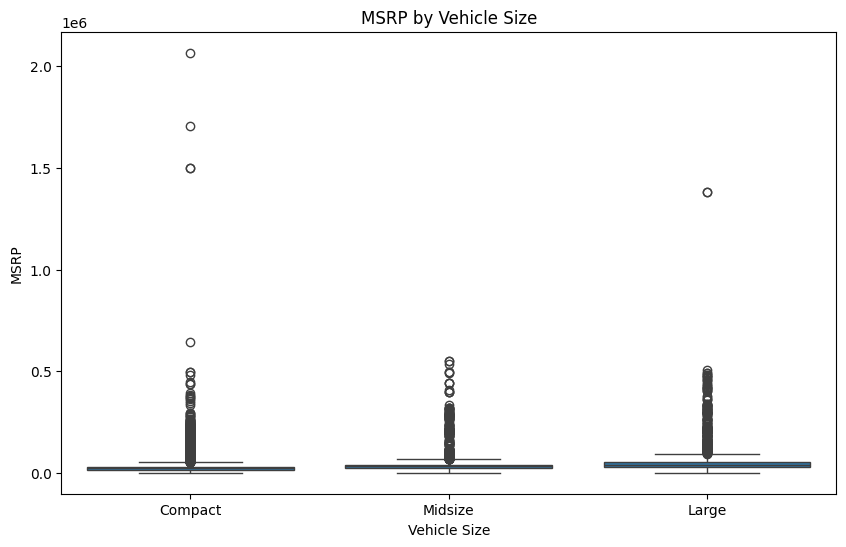

In [81]:
# Plot a boxplot of MSRP grouped by Vehicle Size.
plt.figure(figsize=(10, 6))
sns.boxplot(x="Vehicle Size", y="MSRP", data=df)
plt.xlabel("Vehicle Size")
plt.ylabel("MSRP")
plt.title("MSRP by Vehicle Size")
plt.show()

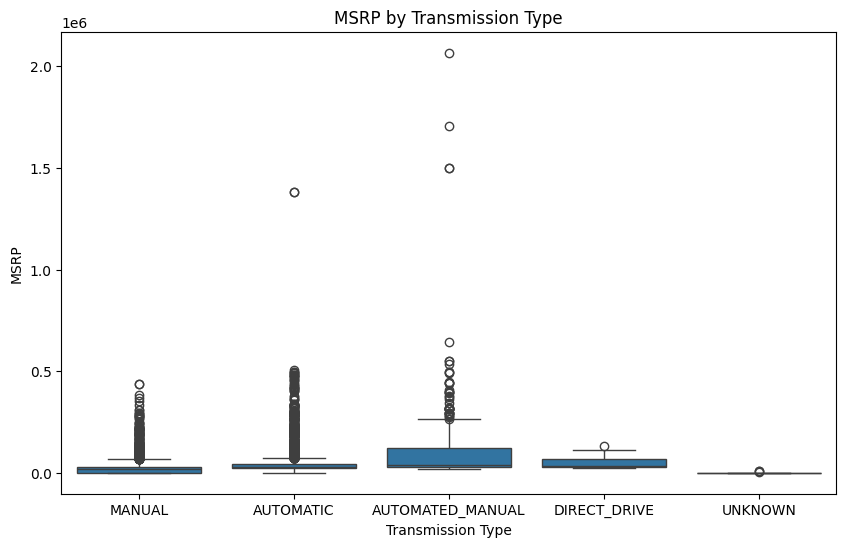

In [82]:
# Plot a boxplot of MSRP grouped by Transmission Type.
plt.figure(figsize=(10, 6))
sns.boxplot(x="Transmission Type", y="MSRP", data=df)
plt.xlabel("Transmission Type")
plt.ylabel("MSRP")
plt.title("MSRP by Transmission Type")
plt.show()

In [83]:
# Compare average Engine HP across Driven_Wheels categories.
avg_EH_HP = df.groupby("Driven_Wheels")["Engine HP"].mean()
print(avg_EH_HP)

Driven_Wheels
all wheel drive      290.402540
four wheel drive     274.975766
front wheel drive    184.060032
rear wheel drive     302.872171
Name: Engine HP, dtype: float64


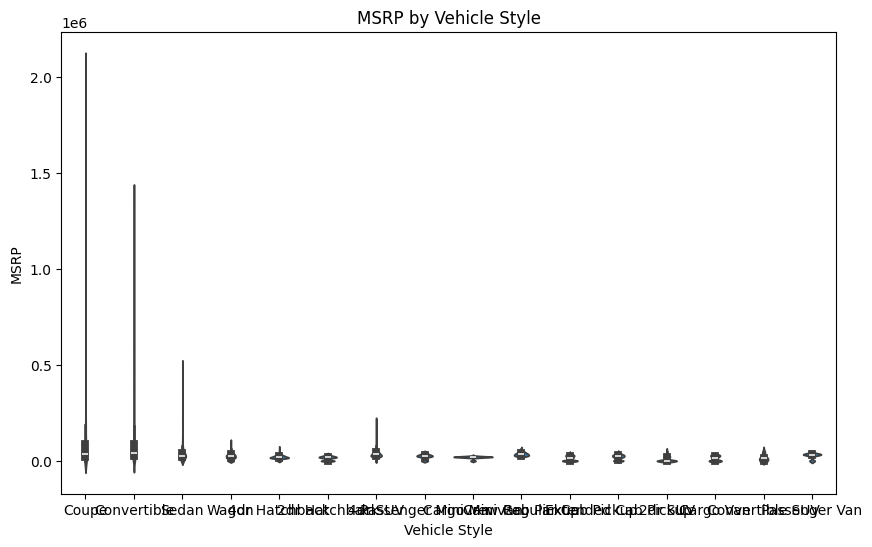

In [84]:
# Plot a violin plot of MSRP by Vehicle Style.
plt.figure(figsize=(10, 6))
sns.violinplot(x="Vehicle Style", y="MSRP", data=df)
plt.xlabel("Vehicle Style")
plt.ylabel("MSRP")
plt.title("MSRP by Vehicle Style")
plt.show()

In [85]:
# Which Vehicle Size category has the highest average MSRP?
avg_mrsp = df.groupby("Vehicle Size")["MSRP"].mean()
print(avg_mrsp)

Vehicle Size
Compact    34275.336482
Large      53890.500540
Midsize    39035.919049
Name: MSRP, dtype: float64


In [86]:
# Compare city mpg across different Engine Fuel Type categories.
avg_city_mpg = df.groupby("Engine Fuel Type")["city mpg"].mean()
print(avg_city_mpg)

Engine Fuel Type
diesel                                           26.376623
electric                                        112.696970
flex-fuel (premium unleaded recommended/E85)     16.923077
flex-fuel (premium unleaded required/E85)        13.296296
flex-fuel (unleaded/E85)                         16.169077
flex-fuel (unleaded/natural gas)                 17.000000
natural gas                                      27.000000
premium unleaded (recommended)                   20.406435
premium unleaded (required)                      16.680936
regular unleaded                                 19.952753
Name: city mpg, dtype: float64


In [87]:
# Find which Make has the highest average Engine HP.
avg_EH_HP = df.groupby("Make")["Engine HP"].mean()
print(avg_EH_HP)

Make
Acura             244.797619
Alfa Romeo        237.000000
Aston Martin      484.322581
Audi              277.695122
BMW               326.907186
Bentley           533.851351
Bugatti          1001.000000
Buick             219.244898
Cadillac          332.309824
Chevrolet         246.985144
Chrysler          229.139037
Dodge             244.415335
FIAT              148.679971
Ferrari           511.956522
Ford              243.190714
GMC               259.844660
Genesis           347.333333
HUMMER            261.235294
Honda             195.988357
Hyundai           201.917492
Infiniti          310.066667
Kia               207.748616
Lamborghini       614.076923
Land Rover        322.097902
Lexus             277.415842
Lincoln           283.177369
Lotus             275.965517
Maserati          420.793103
Maybach           590.500000
Mazda             171.992908
McLaren           610.400000
Mercedes-Benz     349.896278
Mitsubishi        173.785850
Nissan            240.091148
Oldsmobil

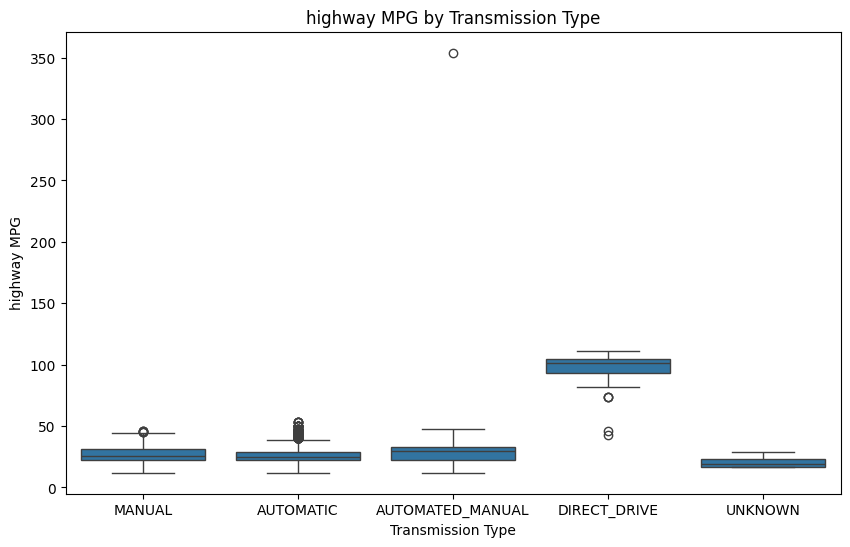

In [88]:
# Plot a boxplot of highway MPG grouped by Transmission Type.
plt.figure(figsize=(10, 6))
sns.boxplot(x="Transmission Type", y="highway MPG", data=df)
plt.xlabel("Transmission Type")
plt.ylabel("highway MPG")
plt.title("highway MPG by Transmission Type")
plt.show()

In [89]:
# Compare the average MSRP for automatic vs manual transmission cars.
avg_MSRP_TC = df.groupby("Transmission Type")["MSRP"].mean()
print(avg_MSRP_TC)

Transmission Type
AUTOMATED_MANUAL    99508.370607
AUTOMATIC           41110.331720
DIRECT_DRIVE        47351.250000
MANUAL              26663.644293
UNKNOWN              3040.736842
Name: MSRP, dtype: float64


**Categorical vs Categorical**

In [90]:
# Create a crosstab between Vehicle Size and Transmission Type.
crosstab_V_T = pd.crosstab(df["Vehicle Size"], df["Transmission Type"])
print(crosstab_V_T)

Transmission Type  AUTOMATED_MANUAL  AUTOMATIC  DIRECT_DRIVE  MANUAL  UNKNOWN
Vehicle Size                                                                 
Compact                         416       2124            45    2173        6
Large                            38       2464            18     249        8
Midsize                         172       3678             5     513        5


In [91]:
# Create a crosstab between Driven_Wheels and Vehicle Style.
crosstab_DW_VS = pd.crosstab(df["Driven_Wheels"], df["Vehicle Style"])
print(crosstab_DW_VS)

Vehicle Style      2dr Hatchback  2dr SUV  4dr Hatchback  4dr SUV  \
Driven_Wheels                                                       
all wheel drive               10       11            101      984   
four wheel drive               2       69              7      496   
front wheel drive            473        0            583      631   
rear wheel drive              21       58             11      377   

Vehicle Style      Cargo Minivan  Cargo Van  Convertible  Convertible SUV  \
Driven_Wheels                                                               
all wheel drive                6          2          106                5   
four wheel drive               0          0            0               15   
front wheel drive             54          0          236                0   
rear wheel drive              11         93          451                9   

Vehicle Style      Coupe  Crew Cab Pickup  Extended Cab Pickup  \
Driven_Wheels                                           

<Axes: xlabel='Vehicle Size'>

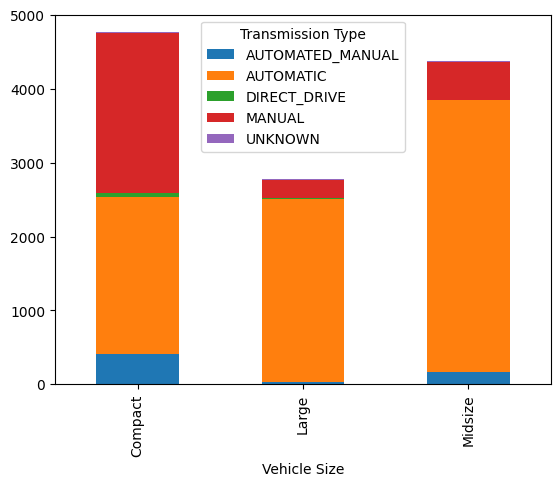

In [92]:
from pandas.core.reshape.pivot import crosstab
#Plot a stacked bar chart of Vehicle Size vs Transmission Type.
crosstab_V_T.plot(kind="bar", stacked=True)



In [93]:
#Check the association between Engine Fuel Type and Driven_Wheels using a chi-square test.
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df["Engine Fuel Type"], df["Driven_Wheels"])
chi2, p, dof, expected = chi2_contingency(contingency_table)

In [94]:
print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 2831.123574632926
P-value: 0.0


In [95]:
#Which Vehicle Style is most common within each Vehicle Size group?
df.groupby("Vehicle Size")["Vehicle Style"].value_counts()

Vehicle Size  Vehicle Style      
Compact       Coupe                   679
              Sedan                   625
              4dr Hatchback           623
              Convertible             587
              4dr SUV                 534
              2dr Hatchback           497
              Extended Cab Pickup     292
              Wagon                   272
              Crew Cab Pickup         258
              Regular Cab Pickup      125
              Passenger Minivan        99
              2dr SUV                  89
              Cargo Minivan            41
              Convertible SUV          26
              Cargo Van                10
              Passenger Van             7
Large         Sedan                   813
              4dr SUV                 501
              Crew Cab Pickup         423
              Extended Cab Pickup     331
              Regular Cab Pickup      267
              Passenger Minivan       116
              Coupe                   112
              Wagon                   104
              Passenger Van            37
              Cargo Van                34
              Cargo Minivan            15
              Convertible              14
              4dr Hatchback            10
Midsize       Sedan                  1610
              4dr SUV                1453
              Coupe                   420
              Wagon                   216
              Passenger Minivan       202
              Convertible             192
              Passenger Van            84
              4dr Hatchback            69
              Cargo Van                51
              2dr SUV                  49
              Cargo Minivan            15
              2dr Hatchback             9
              Convertible SUV           3
Name: count, dtype: int64

**MSRP-Focused (Target Variable)**

In [96]:
#Find the top 10 most expensive cars by MSRP.
df.nlargest(10, "MSRP")

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,log_MSRP
11362,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,2065902,14.541077
11364,Bugatti,Veyron 16.4,2009,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,1705769,14.349527
8486,Lamborghini,Reventon,2008,premium unleaded (required),650.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,9,1158,1500000,14.220976
11363,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,1500000,14.220976
6351,Maybach,Landaulet,2012,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Convertible,16,10,67,1382750,14.139585
6350,Maybach,Landaulet,2011,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,High-Performance",Large,Convertible,16,10,67,1380000,14.137594
4024,Ferrari,Enzo,2003,premium unleaded (required),660.0,12.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,12,7,2774,643330,13.374413
1622,Lamborghini,Aventador,2014,premium unleaded (required),720.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Midsize,Convertible,16,10,1158,548800,13.215489
1626,Lamborghini,Aventador,2015,premium unleaded (required),720.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Midsize,Convertible,16,10,1158,548800,13.215489
1629,Lamborghini,Aventador,2016,premium unleaded (required),750.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Midsize,Convertible,18,11,1158,535500,13.190956


In [97]:
# Find the top 10 most expensive cars by MSRP.
df.nsmallest(10, "MSRP")

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,log_MSRP
17,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,7.600902
18,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,7.600902
19,Audi,100,1992,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Wagon,20,16,3105,2000,7.600902
20,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,7.600902
21,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,all wheel drive,4.0,Luxury,Midsize,Sedan,21,16,3105,2000,7.600902
22,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,7.600902
23,Audi,100,1993,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Wagon,20,16,3105,2000,7.600902
24,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,7.600902
25,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,7.600902
26,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,all wheel drive,4.0,Luxury,Midsize,Sedan,21,16,3105,2000,7.600902


In [98]:
# Which Make has the widest range (max - min) of MSRP?
df.groupby("Make")["MSRP"].agg(["min", "max"])

,min,max
Make,,
Acura,2000,156000
Alfa Romeo,53900,68400
Aston Martin,98200,320695
Audi,2000,199900
BMW,4697,141200
Bentley,177500,363000
Bugatti,1500000,2065902
Buick,2000,49625
Cadillac,2000,104215


In [99]:
# Group by Make and find the average MSRP per brand, sorted descending.
avg_msrp = df.groupby('Make')['MSRP'].mean().sort_values(ascending=False)
print(avg_msrp)

Make
Bugatti          1.757224e+06
Maybach          5.462219e+05
Rolls-Royce      3.511306e+05
Lamborghini      3.315673e+05
Bentley          2.471693e+05
McLaren          2.398050e+05
Ferrari          2.382188e+05
Spyker           2.133233e+05
Aston Martin     1.979104e+05
Maserati         1.142077e+05
Porsche          1.016224e+05
Tesla            8.525556e+04
Mercedes-Benz    7.147623e+04
Lotus            6.918828e+04
Land Rover       6.782322e+04
Alfa Romeo       6.160000e+04
BMW              6.154676e+04
Cadillac         5.623132e+04
Audi             5.345211e+04
Lexus            4.754907e+04
Genesis          4.661667e+04
Lincoln          4.283983e+04
Infiniti         4.239421e+04
HUMMER           3.646441e+04
Acura            3.488759e+04
GMC              3.049330e+04
Toyota           2.903002e+04
Nissan           2.858343e+04
Volvo            2.854116e+04
Chevrolet        2.835039e+04
Buick            2.820661e+04
Volkswagen       2.810238e+04
Saab             2.741350e+04
Ford 

In [100]:
#Identify cars where MSRP is unusually high compared to their Engine HP (potential outliers/luxury brands).
df["MSRP_per_Engine_HP"] = df["MSRP"] / df["Engine HP"]
df.nlargest(10, "MSRP_per_Engine_HP")

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,log_MSRP,MSRP_per_Engine_HP
8486,Lamborghini,Reventon,2008,premium unleaded (required),650.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,9,1158,1500000,14.220976,2307.692308
6351,Maybach,Landaulet,2012,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Convertible,16,10,67,1382750,14.139585,2230.241935
6350,Maybach,Landaulet,2011,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,High-Performance",Large,Convertible,16,10,67,1380000,14.137594,2225.806452
11362,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,2065902,14.541077,2063.838162
11364,Bugatti,Veyron 16.4,2009,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,1705769,14.349527,1704.064935
11363,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,1500000,14.220976,1498.501499
2921,Rolls-Royce,Corniche,2001,premium unleaded (required),325.0,8.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,Luxury",Large,Convertible,15,10,86,359990,12.793832,1107.661538
7564,Rolls-Royce,Phantom,2016,premium unleaded (required),453.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Sedan,19,11,86,492425,13.107097,1087.030905
7558,Rolls-Royce,Phantom Drophead Coupe,2016,premium unleaded (required),453.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,Luxury,Performance",Large,Convertible,19,11,86,492000,13.106234,1086.092715
7562,Rolls-Royce,Phantom,2015,premium unleaded (required),453.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Sedan,19,11,86,480175,13.081906,1059.988962


**Section D: Multivariate Analysis**

In [101]:
#Create a correlation matrix of all numerical columns (Year, Engine HP, Engine Cylinders, Number of Doors, highway MPG, city mpg, Popularity, MSRP).
numerical_cols = ["Year", "Engine HP", "Engine Cylinders", "Number of Doors", "highway MPG", "city mpg", "Popularity", "MSRP"]
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

                      Year  Engine HP  Engine Cylinders  Number of Doors  \
Year              1.000000   0.351288         -0.041336         0.263946   
Engine HP         0.351288   1.000000          0.765251        -0.102303   
Engine Cylinders -0.041336   0.765251          1.000000        -0.141054   
Number of Doors   0.263946  -0.102303         -0.141054         1.000000   
highway MPG       0.258240  -0.353343         -0.607422         0.118925   
city mpg          0.198171  -0.346308         -0.574382         0.121206   
Popularity        0.073049   0.037315          0.042431        -0.048251   
MSRP              0.227590   0.661644          0.531171        -0.126081   

                  highway MPG  city mpg  Popularity      MSRP  
Year                 0.258240  0.198171    0.073049  0.227590  
Engine HP           -0.353343 -0.346308    0.037315  0.661644  
Engine Cylinders    -0.607422 -0.574382    0.042431  0.531171  
Number of Doors      0.118925  0.121206   -0.048251 -0.1260

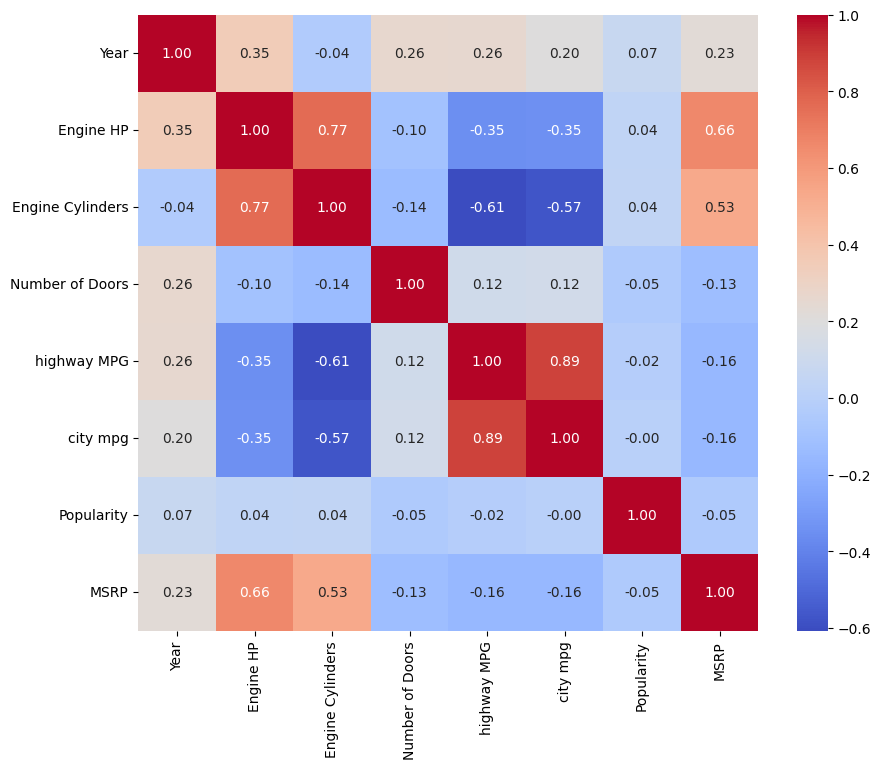

In [102]:
# Plot a heatmap of this correlation matrix.
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

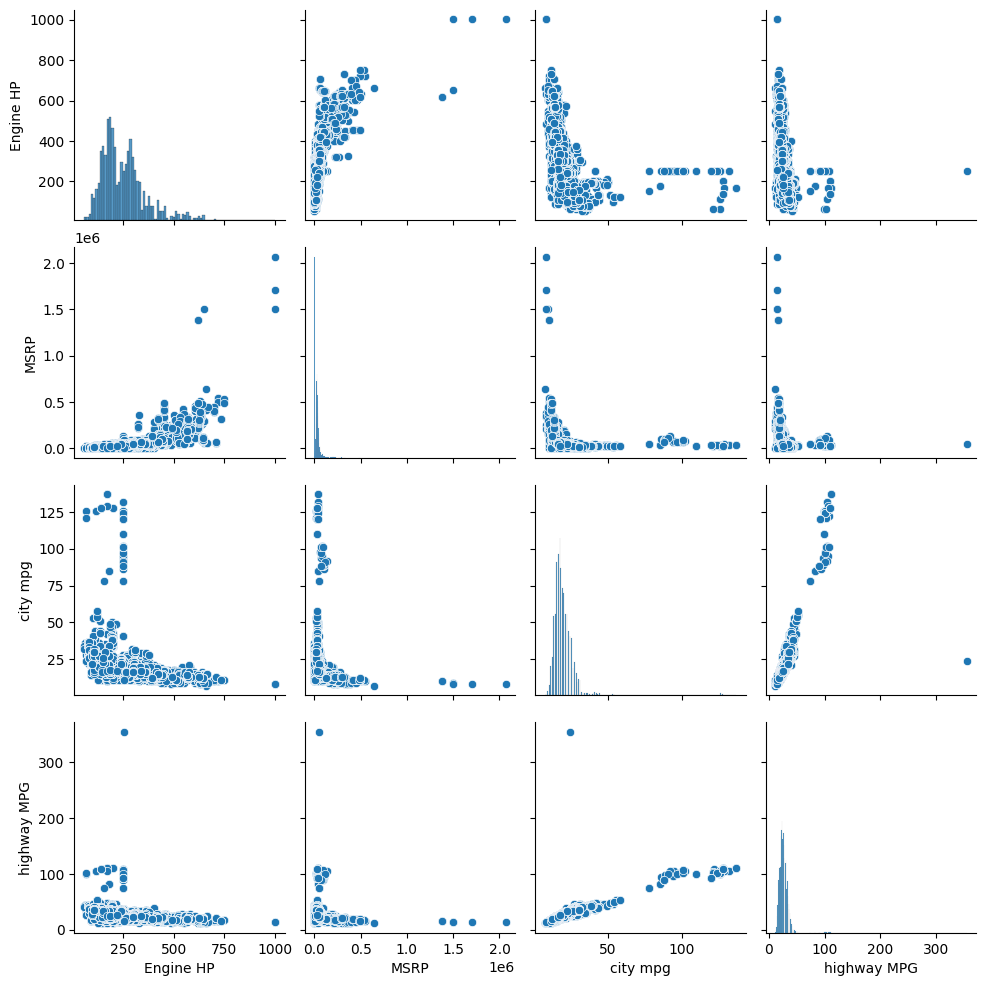

In [103]:
# Create a pairplot of Engine HP, MSRP, city mpg, and highway MPG.
sns.pairplot(df[["Engine HP", "MSRP", "city mpg", "highway MPG"]])
plt.show()

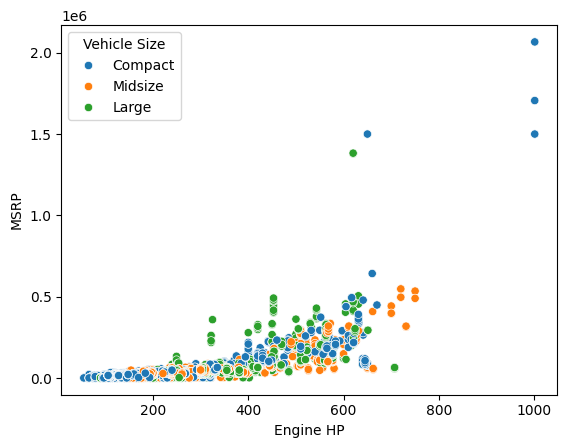

In [104]:
#Plot a scatter plot of Engine HP vs MSRP, colored by Vehicle Size (hue).
sns.scatterplot(data=df, x="Engine HP", y="MSRP", hue="Vehicle Size")
plt.show()

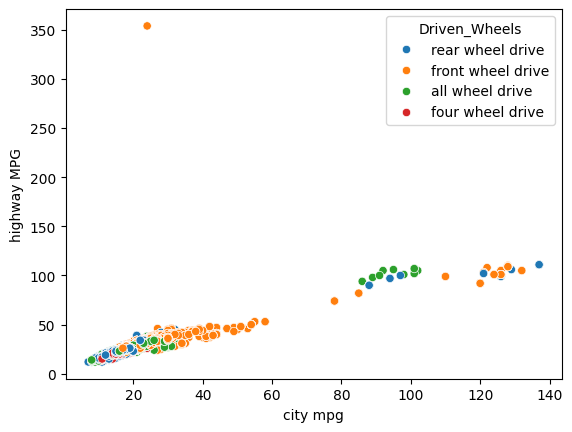

In [105]:
# Plot a scatter plot of city mpg vs highway MPG, colored by Driven_Wheels.
sns.scatterplot(data=df, x="city mpg", y="highway MPG", hue="Driven_Wheels")
plt.show()

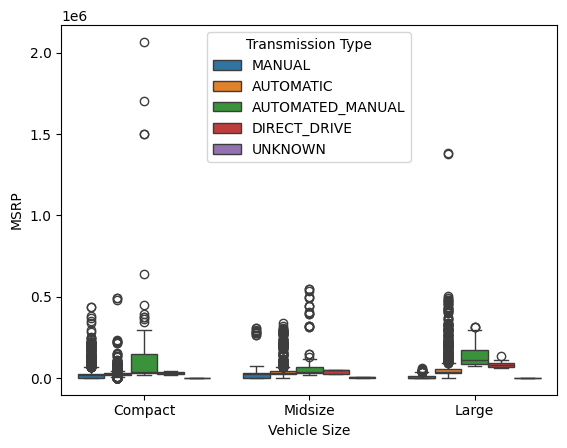

In [106]:
#Create a boxplot of MSRP across Vehicle Size, split further by Transmission Type (using hue).
sns.boxplot(data=df, x="Vehicle Size", y="MSRP", hue="Transmission Type")
plt.show()

In [107]:
correlation_matrix = df.corr(numeric_only=True)["MSRP"].sort_values(ascending=False)
print(correlation_matrix)

MSRP                  1.000000
MSRP_per_Engine_HP    0.896717
Engine HP             0.661644
log_MSRP              0.596519
Engine Cylinders      0.531171
Year                  0.227590
Popularity           -0.048476
Number of Doors      -0.126081
city mpg             -0.157676
highway MPG          -0.160043
Name: MSRP, dtype: float64


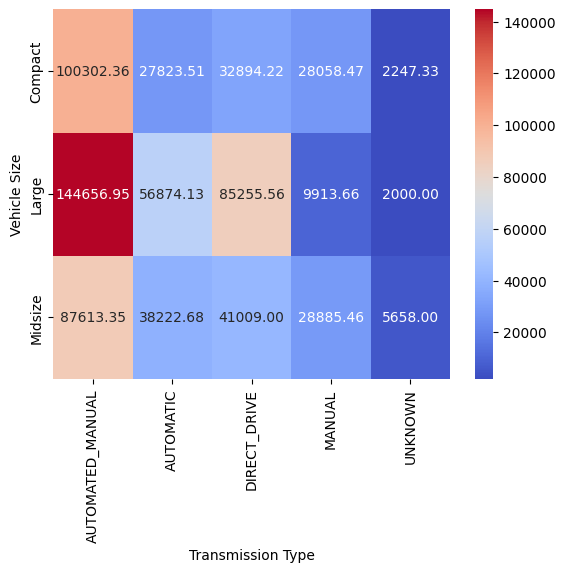

In [108]:
# Create a heatmap where rows = Vehicle Size, columns = Transmission Type, values = average MSRP.
pivot_table = df.pivot_table(index="Vehicle Size", columns="Transmission Type", values="MSRP", aggfunc="mean")
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

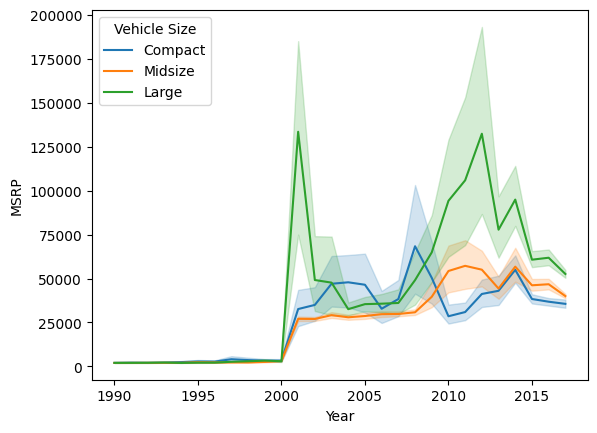

In [109]:
#Compare MSRP trends over Year, separately for each Vehicle Size (line plot).
sns.lineplot(data=df, x="Year", y="MSRP", hue="Vehicle Size")
plt.show()

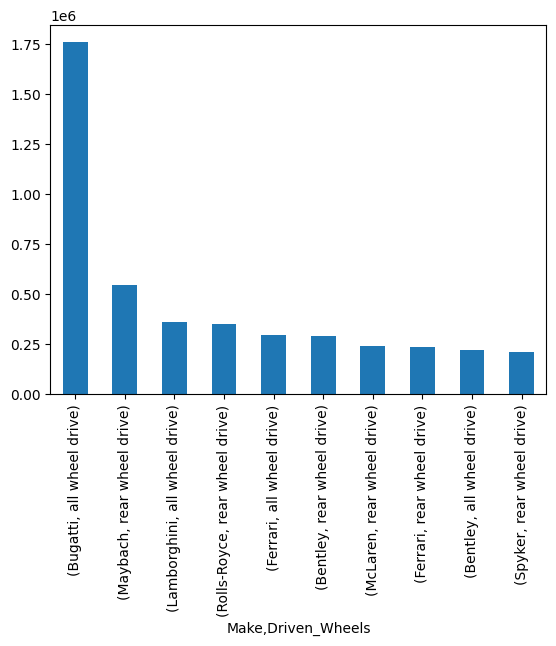

In [110]:
#Build a grouped bar chart: average MSRP by Make (top 10), split by Driven_Wheels.
avg_msrp = df.groupby(["Make", "Driven_Wheels"])["MSRP"].mean().nlargest(10)
avg_msrp.plot(kind="bar")
plt.show()

In [111]:
# Identify which combination of Engine Cylinders + Driven_Wheels gives the highest average MSRP.
avg_msrp = df.groupby(["Engine Cylinders", "Driven_Wheels"])["MSRP"].mean()
print(avg_msrp)

Engine Cylinders  Driven_Wheels    
0.0               all wheel drive      9.063636e+04
                  front wheel drive    3.320721e+04
                  rear wheel drive     6.440000e+04
3.0               four wheel drive     2.000000e+03
                  front wheel drive    1.088231e+04
4.0               all wheel drive      3.353528e+04
                  four wheel drive     1.384931e+04
                  front wheel drive    2.166280e+04
                  rear wheel drive     2.312638e+04
5.0               all wheel drive      3.143869e+04
                  four wheel drive     3.254000e+04
                  front wheel drive    1.654917e+04
                  rear wheel drive     1.435333e+04
6.0               all wheel drive      4.771330e+04
                  four wheel drive     2.942305e+04
                  front wheel drive    2.653547e+04
                  rear wheel drive     3.325419e+04
8.0               all wheel drive      9.463197e+04
                  four wheel

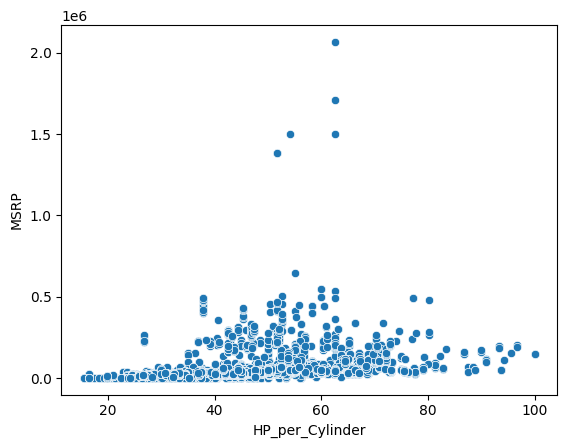

In [112]:
#Create an interaction feature: Engine HP per Engine Cylinder (HP/cylinder ratio) and analyze its relationship with MSRP.
df["HP_per_Cylinder"] = df["Engine HP"] / df["Engine Cylinders"]
sns.scatterplot(data=df, x="HP_per_Cylinder", y="MSRP")
plt.show()

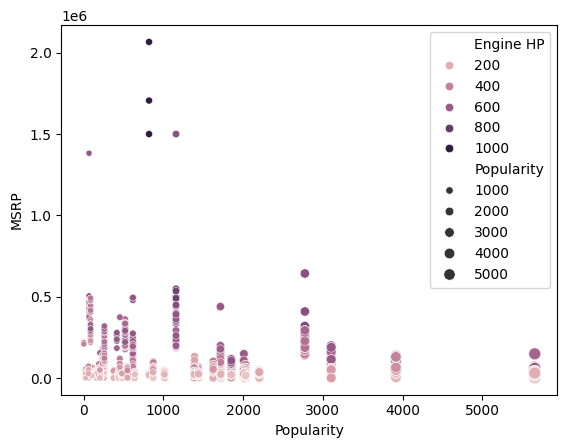

In [113]:
#Compare Popularity vs MSRP vs Engine HP together in a bubble chart (size = Popularity).
sns.scatterplot(data=df, x="Popularity", y="MSRP", size="Popularity", hue="Engine HP")
plt.show()

In [114]:
#Analyze how MSRP varies across Make, Vehicle Size, and Transmission Type together (groupby with multiple keys).
avg_msrp = df.groupby(["Make", "Vehicle Size", "Transmission Type"])["MSRP"].mean()
print(avg_msrp)

Make   Vehicle Size  Transmission Type
Acura  Compact       AUTOMATED_MANUAL     40761.538462
                     AUTOMATIC            32061.764706
                     MANUAL               18741.593750
       Midsize       AUTOMATED_MANUAL     41017.500000
                     AUTOMATIC            41691.825806
                                              ...     
Volvo  Compact       AUTOMATIC            31530.277778
                     MANUAL               27572.222222
       Large         AUTOMATIC            51984.210526
       Midsize       AUTOMATIC            30438.460396
                     MANUAL                2063.696970
Name: MSRP, Length: 225, dtype: float64


In [131]:
# download cleaned file
df.to_csv("cleaned_car_MSR_data.csv", index=False)